In [25]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import geopandas as gpd
from scipy.stats import gaussian_kde

In [26]:
s2_dnbr_dir = r'/Volumes/PhD/imagery/masters/output/dNBR/'
av_HM1_dir = r'/Volumes/PhD/imagery/masters/output/hyper_compare/HM1/'
av_OHM1_dir = r'/Volumes/PhD/imagery/masters/output/hyper_compare/OHM1/'


Mont_shp = gpd.read_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_Prob.shp')
basin = '17346'

In [27]:
# for any basin specified by the basin variable, this code will read in the dNBR, NBR, and HM1 rasters, extract the values, and plot the distributions of each. 
dnbr = rxr.open_rasterio(s2_dnbr_dir + f'basin_{basin}_dNBR.tif', masked=True).squeeze()
hm1_dnbr = rxr.open_rasterio(av_HM1_dir + f'Basin_{basin}_dNBR.tif', masked=True).squeeze()
ohm1_dnbr = rxr.open_rasterio(av_OHM1_dir + f'Basin_{basin}_dNBR.tif', masked=True).squeeze()

In [28]:
# grab the highest mean for the ohm1 dNBR

x = ohm1_dnbr.values.flatten()
x = x[~np.isnan(x)]  # remove NaNs just in case

# fit KDE
kde = gaussian_kde(x)

# evaluate over a fine grid
x_grid = np.linspace(x.min(), x.max(), 1000)
y_kde = kde(x_grid)

# highest mode = x where KDE is maximum
highest_mode = x_grid[np.argmax(y_kde)]

print("Highest KDE mode:", highest_mode)


Highest KDE mode: 0.7866401


In [29]:
sec_data = Mont_shp[Mont_shp['BASIN_ID'] == int(basin)]

In [30]:
sec_data.columns

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR', 'HM1M_dNBR',
       'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR', 'OHM1Md_dNB',
       'OHM1PF_dNB', 'OHM1Q1_dNB', 'M1M_prob', 'M1Md_prob', 'M1PF_prob',
       'M1Q1_prob', 'HM1M_prob', 'HM1Md_prob', 'HM1PF_prob', 'HM1Q1_prob',
       'OHM1M_prob', 'OHM1Md_pro', 'OHM1PF_pro', 'OHM1Q1_pro', 'Old_ROC',
       'geometry'],
      dtype='object')

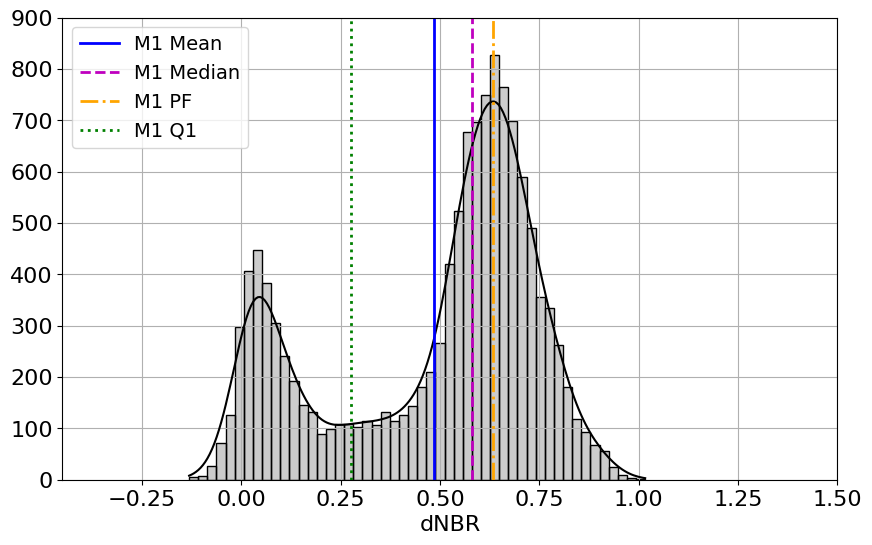

In [33]:
# plot the distribution of dNBR values for the specified basin, 
plt.figure(figsize=(10,6))
sns.histplot(dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2)
plt.axvline(sec_data['M1M_dNBR'].values[0], color='blue', linestyle='-', linewidth=2, label='M1 Mean')
plt.axvline(sec_data['M1Md_dNBR'].values[0], color='m', linestyle='--', linewidth=2, label='M1 Median')
plt.axvline(sec_data['M1PF_dNBR'].values[0], color='orange', linestyle='-.', linewidth=2, label='M1 PF')
plt.axvline(sec_data['M1Q1_dNBR'].values[0], color='g', linestyle=':', linewidth=2, label='M1 Q1')
plt.legend(loc='upper left', fontsize=14)
plt.xlabel('dNBR', fontsize=16)
plt.ylabel('', fontsize=24, fontweight='bold')
plt.ylim(0,900)

# increase x and y axis size of numbers
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.xlim(-.45, 1.5)
plt.grid()
plt.savefig(f'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/SI/basin_{basin}_dNBR_dist.svg', dpi=600)
plt.show()

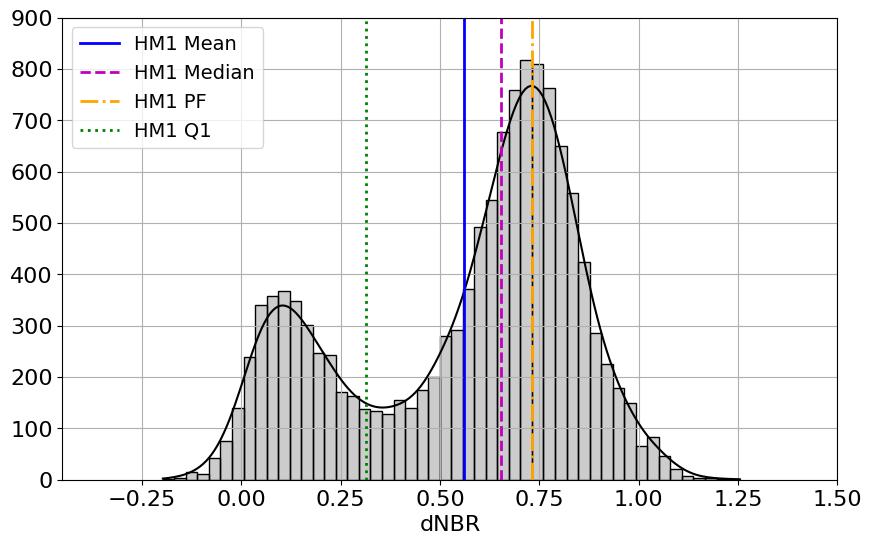

In [34]:
# plot the distribution of dNBR values for the specified basin, 
plt.figure(figsize=(10,6))
sns.histplot(hm1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2)
plt.axvline(sec_data['HM1M_dNBR'].values[0], color='blue', linestyle='-', linewidth=2, label='HM1 Mean')
plt.axvline(sec_data['HM1Md_dNBR'].values[0], color='m', linestyle='--', linewidth=2, label='HM1 Median')
plt.axvline(sec_data['HM1PF_dNBR'].values[0], color='orange', linestyle='-.', linewidth=2, label='HM1 PF')
plt.axvline(sec_data['HM1Q1_dNBR'].values[0], color='g', linestyle=':', linewidth=2, label='HM1 Q1')
plt.legend(loc='upper left', fontsize=14)
plt.xlabel('dNBR', fontsize=16)
plt.ylabel('', fontsize=24, fontweight='bold')

# increase x and y axis size of numbers
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,900)
plt.xlim(-.45, 1.5)
plt.grid()
plt.savefig(f'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/SI/basin_{basin}_HM1dNBR_dist.svg', dpi=600)
plt.show()

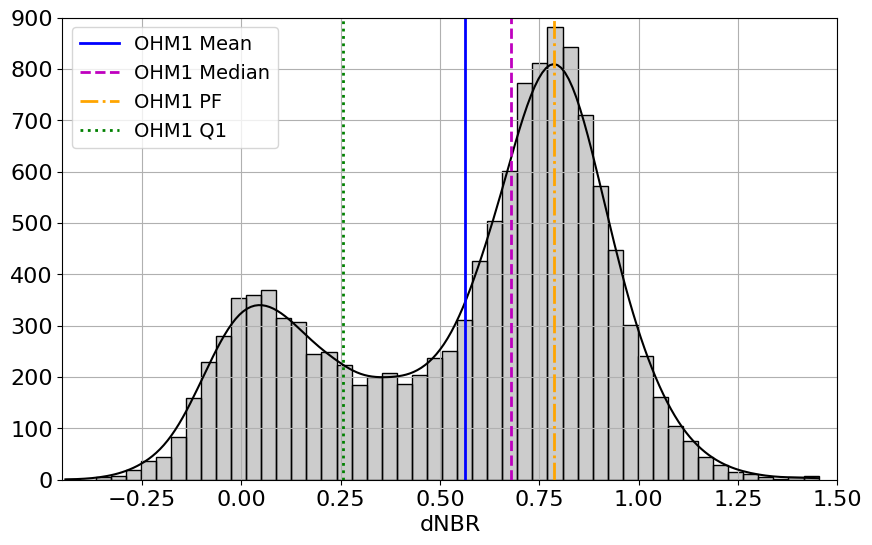

In [37]:
# plot the distribution of dNBR values for the specified basin, 
plt.figure(figsize=(10,6))
sns.histplot(ohm1_dnbr.values.flatten(), bins=50, color='black', kde=True, alpha=0.2)
plt.axvline(sec_data['OHM1M_dNBR'].values[0], color='blue', linestyle='-', linewidth=2, label='OHM1 Mean')
plt.axvline(sec_data['OHM1Md_dNB'].values[0], color='m', linestyle='--', linewidth=2, label='OHM1 Median')
plt.axvline(highest_mode, color='orange', linestyle='-.', linewidth=2, label='OHM1 PF')
plt.axvline(sec_data['OHM1Q1_dNB'].values[0], color='g', linestyle=':', linewidth=2, label='OHM1 Q1')
plt.legend(loc='upper left', fontsize=14)
plt.xlabel('dNBR', fontsize=16)
plt.ylabel('', fontsize=24, fontweight='bold')
plt.ylim(0,900)
# increase x and y axis size of numbers
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(100))

plt.xlim(-.45, 1.5)
plt.grid()
plt.savefig(f'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/SI/basin_{basin}_OHM1dNBR_dist.svg', dpi=600)
plt.show()